# CIS433 — Project 3: English → Spanish Transformer Translator
### Colab Version (T4 GPU)

**Files live in:** `My Drive/CIS433_Project3_spa/`  
**Run order:** Run every cell top-to-bottom. Do not skip any cell.  
**First time:** Runtime → Change runtime type → T4 GPU → Save


## 1 · Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')
print("Drive mounted.")


Mounted at /content/drive
Drive mounted.


## 2 · Install & Imports

In [2]:
!pip install sacrebleu -q

import sacrebleu
import sys, os, re, pickle, time, math, shutil
from pathlib import Path
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt

print(f'PyTorch version : {torch.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU             : {torch.cuda.get_device_name(0)}')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 9.2 MB/s eta 0:00:00
PyTorch version : 2.10.0+cu128
CUDA available  : True
GPU             : Tesla T4


## 3 · Paths & Device

In [3]:
# ── Device ───────────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# ── Drive paths ───────────────────────────────────────────────────────────────
DRIVE_DIR   = Path('/content/drive/MyDrive/CIS433_Project3_spa')
DATA_PATH   = DRIVE_DIR / 'spa.txt'
TRANSFORMER = DRIVE_DIR / 'rui_torch_transformer.py'

# ── Local working dir (fast SSD on Colab, not Drive) ─────────────────────────
WORK_DIR  = Path('/content/project3')
MODEL_DIR = WORK_DIR / 'saved_model'
WORK_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)

# Copy transformer file to local working dir so import works
shutil.copy(TRANSFORMER, WORK_DIR / 'rui_torch_transformer.py')

assert DATA_PATH.exists(),   f'spa.txt not found: {DATA_PATH}'
assert (WORK_DIR / 'rui_torch_transformer.py').exists(), 'transformer file not copied'

print(f'Data      : {DATA_PATH}')
print(f'Model dir : {MODEL_DIR}')
print(f'Work dir  : {WORK_DIR}')


Using device: cuda
Data      : /content/drive/MyDrive/CIS433_Project3_spa/spa.txt
Model dir : /content/project3/saved_model
Work dir  : /content/project3


## 4 · Import Transformer & Patch Cross-Attention

In [4]:
sys.path.insert(0, str(WORK_DIR))
from rui_torch_transformer import (
    Transformer, MultiHeadAttention,
    Encoder, Decoder, PositionalEmbedding,
    FeedForward, EncoderLayer, DecoderLayer,
)
print('rui_torch_transformer imported')

def _mha_forward(self, q, k, v):
    b, q_len, _ = q.shape
    kv_len = k.shape[1]
    q = self.W_q(q)
    k = self.W_k(k)
    v = self.W_v(v)
    q = q.view(b, q_len,  self.n_heads, self.d_k).transpose(1, 2)
    k = k.view(b, kv_len, self.n_heads, self.d_k).transpose(1, 2)
    v = v.view(b, kv_len, self.n_heads, self.d_k).transpose(1, 2)
    scores = q @ k.transpose(2, 3)
    if self.is_causal:
        mask = self.mask.bool()[:q_len, :q_len]
        scores.masked_fill_(mask, -torch.inf)
    weights = torch.softmax(scores / self.d_k**0.5, dim=-1)
    weights = self.dropout(weights)
    out = (weights @ v).transpose(1, 2)
    out = out.contiguous().view(b, q_len, self.d_model)
    return self.out_proj(out)

MultiHeadAttention.forward = _mha_forward
print('MultiHeadAttention patched for variable-length cross-attention')


Transformer imported from local file "rui_torch_transformer.py"
rui_torch_transformer imported
MultiHeadAttention patched for variable-length cross-attention


## 5 · Tokeniser & Vocabulary

In [5]:
def tokenize(text, lang='en'):
    text = text.lower().strip()
    text = re.sub(r"([?.!,¿¡;:])", r" \1 ", text)
    allowed = r'[^a-z?.!,¿¡;: ]+' if lang == 'en' else r'[^a-záéíóúüñ?.!,¿¡;: ]+'
    text = re.sub(allowed, ' ', text)
    return text.split()


class Vocab:
    PAD, UNK, SOS, EOS = 0, 1, 2, 3
    _SPECIALS = {'<PAD>': 0, '<UNK>': 1, '<SOS>': 2, '<EOS>': 3}

    def __init__(self, max_size=14_000):
        self.max_size = max_size
        self.word2idx = dict(self._SPECIALS)
        self.idx2word = {v: k for k, v in self._SPECIALS.items()}

    def build(self, tokenized_sentences):
        freq = Counter(tok for sent in tokenized_sentences for tok in sent)
        for word, _ in freq.most_common(self.max_size - len(self._SPECIALS)):
            idx = len(self.word2idx)
            self.word2idx[word] = idx
            self.idx2word[idx]  = word
        print(f'  vocab size: {len(self.word2idx):,}')

    def encode(self, tokens, add_sos=False, add_eos=False):
        ids = []
        if add_sos: ids.append(self.SOS)
        ids += [self.word2idx.get(t, self.UNK) for t in tokens]
        if add_eos:  ids.append(self.EOS)
        return ids

    def decode(self, ids):
        out = []
        for i in ids:
            if i == self.EOS: break
            if i in (self.PAD, self.SOS): continue
            out.append(self.idx2word.get(i, '<UNK>'))
        return ' '.join(out)

    def __len__(self): return len(self.word2idx)

print('Vocab class defined')


Vocab class defined


## 6 · Load Data & Build Vocabularies

In [6]:
N_LINES   = 118_964   # full dataset
MAX_LEN   = 50
VAL_SPLIT = 0.05
MAX_VOCAB = 14_000
SEED      = 42
torch.manual_seed(SEED)

en_raw, es_raw = [], []
with open(DATA_PATH, 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        if i >= N_LINES: break
        parts = line.strip().split('\t')
        if len(parts) >= 2:
            en_raw.append(parts[0])
            es_raw.append(parts[1])

print(f'Loaded {len(en_raw):,} pairs')

en_tok = [tokenize(s, 'en') for s in en_raw]
es_tok = [tokenize(s, 'es') for s in es_raw]

print('\nBuilding English vocab...')
src_vocab = Vocab(max_size=MAX_VOCAB)
src_vocab.build(en_tok)

print('Building Spanish vocab...')
tgt_vocab = Vocab(max_size=MAX_VOCAB)
tgt_vocab.build(es_tok)

src_enc = [src_vocab.encode(s, add_eos=True)               for s in en_tok]
tgt_enc = [tgt_vocab.encode(s, add_sos=True, add_eos=True) for s in es_tok]

pairs = [(s, t) for s, t in zip(src_enc, tgt_enc)
         if len(s) <= MAX_LEN and len(t) <= MAX_LEN + 1]
print(f'\nPairs after length filter: {len(pairs):,} / {len(src_enc):,}')

src_lens = [len(p[0]) for p in pairs]
tgt_lens = [len(p[1]) for p in pairs]
print(f'Src len  mean={sum(src_lens)/len(src_lens):.1f}  max={max(src_lens)}')
print(f'Tgt len  mean={sum(tgt_lens)/len(tgt_lens):.1f}  max={max(tgt_lens)}')


Loaded 118,964 pairs

Building English vocab...
  vocab size: 12,940
Building Spanish vocab...
  vocab size: 14,000

Pairs after length filter: 118,963 / 118,964
Src len  mean=8.7  max=48
Tgt len  mean=9.3  max=49


## 7 · Dataset & DataLoaders

In [7]:
class TranslationDataset(Dataset):
    def __init__(self, pairs):
        self.pairs = pairs
    def __len__(self):  return len(self.pairs)
    def __getitem__(self, idx):
        s, t = self.pairs[idx]
        return torch.tensor(s, dtype=torch.long), torch.tensor(t, dtype=torch.long)


def collate_fn(batch):
    srcs, tgts = zip(*batch)
    max_s = max(len(x) for x in srcs)
    max_t = max(len(x) for x in tgts)
    src_pad = torch.zeros(len(srcs), max_s, dtype=torch.long)
    tgt_pad = torch.zeros(len(tgts), max_t, dtype=torch.long)
    for i, (s, t) in enumerate(zip(srcs, tgts)):
        src_pad[i, :len(s)] = s
        tgt_pad[i, :len(t)] = t
    return src_pad, tgt_pad


BATCH_SIZE = 256   # larger batch = faster on T4
n_val      = int(len(pairs) * VAL_SPLIT)
n_train    = len(pairs) - n_val
full_ds    = TranslationDataset(pairs)

train_ds, val_ds = random_split(
    full_ds, [n_train, n_val],
    generator=torch.Generator().manual_seed(SEED)
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collate_fn, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate_fn, num_workers=2, pin_memory=True)

print(f'Train : {n_train:,} pairs  ({len(train_loader):,} batches)')
print(f'Val   : {n_val:,} pairs  ({len(val_loader):,} batches)')


Train : 113,015 pairs  (442 batches)
Val   : 5,948 pairs  (24 batches)


## 8 · Model
Config exactly as specified in Project 3.docx.

In [8]:
D_EMB    = 128
N_LAYERS = 2
N_HEADS  = 8
D_FF     = 512

model = Transformer(
    n_layers       = N_LAYERS,
    d_emb          = D_EMB,
    n_heads        = N_HEADS,
    d_ff           = D_FF,
    src_vocab_size = len(src_vocab),
    tgt_vocab_size = len(tgt_vocab),
    seq_len        = MAX_LEN + 2,
    dropout        = 0.1,
).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parameters : {n_params:,}')
print(f'Device     : {device}')

with torch.no_grad():
    dummy_src = torch.zeros(2, 10, dtype=torch.long).to(device)
    dummy_tgt = torch.zeros(2,  8, dtype=torch.long).to(device)
    out = model((dummy_src, dummy_tgt))
    print(f'Forward pass shape: {tuple(out.shape)}  (expected [2, 8, {len(tgt_vocab)}])')


Parameters : 6,177,200
Device     : cuda
Forward pass shape: (2, 8, 14000)  (expected [2, 8, 14000])


## 9 · Training

Checkpoints saved every 5 epochs to Drive so a Colab disconnect loses at most 5 epochs.  
On T4 each epoch takes roughly **60-90 seconds**. Full 20 epochs ~ **25-30 minutes**.


In [9]:
N_EPOCHS     = 20
LR           = 3e-4
CLIP_GRAD    = 1.0
WARMUP_STEPS = 400
CKPT_EVERY   = 5

# Save checkpoints to Drive so disconnects don't lose progress
CKPT_DIR = DRIVE_DIR / 'checkpoints'
CKPT_DIR.mkdir(exist_ok=True)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss(ignore_index=Vocab.PAD, label_smoothing=0.1)

total_steps = N_EPOCHS * len(train_loader)

def lr_lambda(step):
    if step < WARMUP_STEPS:
        return step / max(1, WARMUP_STEPS)
    prog = (step - WARMUP_STEPS) / max(1, total_steps - WARMUP_STEPS)
    return 0.5 * (1.0 + math.cos(math.pi * prog))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

# ── Resume from latest Drive checkpoint if exists ─────────────────────────────
start_epoch = 0
history     = {'train': [], 'val': []}
best_val    = float('inf')

ckpt_files = sorted(CKPT_DIR.glob('checkpoint_ep*.pt'))
if ckpt_files:
    latest = ckpt_files[-1]
    print(f'Resuming from: {latest.name}')
    ckpt = torch.load(latest, map_location=device)
    model.load_state_dict(ckpt['model_state'])
    optimizer.load_state_dict(ckpt['optimizer_state'])
    scheduler.load_state_dict(ckpt['scheduler_state'])
    history     = ckpt.get('history', {'train': [], 'val': []})
    best_val    = ckpt.get('best_val', float('inf'))
    start_epoch = ckpt['epoch']
    print(f'  Resumed at epoch {start_epoch}. Best val so far: {best_val:.4f}')
else:
    print('Starting fresh training.')


def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, total_tokens = 0.0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for src, tgt in loader:
            src     = src.to(device)
            tgt     = tgt.to(device)
            tgt_in  = tgt[:, :-1]
            tgt_out = tgt[:, 1:]
            logits  = model((src, tgt_in))
            loss    = criterion(
                logits.reshape(-1, len(tgt_vocab)),
                tgt_out.reshape(-1)
            )
            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), CLIP_GRAD)
                optimizer.step()
                scheduler.step()
            n_tok        = (tgt_out != Vocab.PAD).sum().item()
            total_loss   += loss.item() * n_tok
            total_tokens += n_tok
    return total_loss / max(1, total_tokens)


print(f'{"Epoch":>5}  {"Train":>9}  {"Val":>9}  {"PPL":>7}  {"LR":>8}  {"Time":>6}')
print('-' * 60)

for epoch in range(start_epoch + 1, N_EPOCHS + 1):
    t0      = time.time()
    tr_loss = run_epoch(train_loader, train=True)
    vl_loss = run_epoch(val_loader,   train=False)
    elapsed = time.time() - t0
    cur_lr  = scheduler.get_last_lr()[0]

    history['train'].append(tr_loss)
    history['val'].append(vl_loss)

    flag = '  <- best' if vl_loss < best_val else ''
    print(f'{epoch:>5}  {tr_loss:>9.4f}  {vl_loss:>9.4f}  '
          f'{math.exp(vl_loss):>7.2f}  {cur_lr:>8.2e}  {elapsed:>5.1f}s{flag}')

    if vl_loss < best_val:
        best_val = vl_loss
        torch.save(model.state_dict(), MODEL_DIR / 'best_model.pt')

    if epoch % CKPT_EVERY == 0:
        ckpt_path = CKPT_DIR / f'checkpoint_ep{epoch:02d}.pt'
        torch.save({
            'epoch':           epoch,
            'model_state':     model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'scheduler_state': scheduler.state_dict(),
            'history':         history,
            'best_val':        best_val,
        }, ckpt_path)
        print(f'  -> checkpoint saved to Drive: {ckpt_path.name}')

print(f'\nBest val loss: {best_val:.4f}  (PPL {math.exp(best_val):.2f})')


Starting fresh training.
Epoch      Train        Val      PPL        LR    Time
------------------------------------------------------------
    1     6.1454     4.4546    86.02  3.00e-04   26.7s  <- best
    2     4.0045     3.4075    30.19  2.98e-04   27.4s  <- best
    3     3.2922     3.0142    20.37  2.91e-04   30.0s  <- best
    4     2.9580     2.8349    17.03  2.81e-04   30.7s  <- best
    5     2.7621     2.7340    15.39  2.67e-04   29.2s  <- best
  -> checkpoint saved to Drive: checkpoint_ep05.pt
    6     2.6252     2.6625    14.33  2.50e-04   30.2s  <- best
    7     2.5275     2.6211    13.75  2.31e-04   30.3s  <- best
    8     2.4515     2.5881    13.30  2.09e-04   29.8s  <- best
    9     2.3937     2.5628    12.97  1.86e-04   30.0s  <- best
   10     2.3465     2.5395    12.67  1.61e-04   30.2s  <- best
  -> checkpoint saved to Drive: checkpoint_ep10.pt
   11     2.3073     2.5317    12.57  1.37e-04   30.0s  <- best
   12     2.2751     2.5168    12.39  1.12e-04   29.9

## 10 · Save Complete Inference Pipeline

Saves everything to both local `/content/project3/saved_model/`  
and back to Drive so you don't lose it when Colab resets.


In [10]:
model.load_state_dict(torch.load(MODEL_DIR / 'best_model.pt', map_location=device))
model.eval()

torch.save(model.state_dict(), MODEL_DIR / 'translator_weights.pt')

with open(MODEL_DIR / 'src_vocab.pkl', 'wb') as f:
    pickle.dump(src_vocab, f)

with open(MODEL_DIR / 'tgt_vocab.pkl', 'wb') as f:
    pickle.dump(tgt_vocab, f)

config = {
    'd_emb':          D_EMB,
    'n_layers':       N_LAYERS,
    'n_heads':        N_HEADS,
    'd_ff':           D_FF,
    'max_len':        MAX_LEN,
    'src_vocab_size': len(src_vocab),
    'tgt_vocab_size': len(tgt_vocab),
}
with open(MODEL_DIR / 'config.pkl', 'wb') as f:
    pickle.dump(config, f)

with open(MODEL_DIR / 'history.pkl', 'wb') as f:
    pickle.dump(history, f)

# ── Mirror everything to Drive ────────────────────────────────────────────────
DRIVE_SAVE = DRIVE_DIR / 'saved_model'
DRIVE_SAVE.mkdir(exist_ok=True)
for f in MODEL_DIR.iterdir():
    if f.suffix in ('.pt', '.pkl', '.png'):
        shutil.copy(f, DRIVE_SAVE / f.name)

print('Saved pipeline locally and mirrored to Drive:')
for p in sorted(MODEL_DIR.iterdir()):
    print(f'  {p.name:<35} {p.stat().st_size / 1024:>8.1f} KB')


Saved pipeline locally and mirrored to Drive:
  best_model.pt                        24229.4 KB
  config.pkl                               0.1 KB
  history.pkl                              0.4 KB
  src_vocab.pkl                          265.7 KB
  tgt_vocab.pkl                          295.5 KB
  translator_weights.pt                24230.0 KB


## 11 · Inference — Load from Disk & Translate

In [20]:
def load_pipeline(model_dir=MODEL_DIR, device=device):
    d = Path(model_dir)
    with open(d / 'src_vocab.pkl', 'rb') as f:  sv  = pickle.load(f)
    with open(d / 'tgt_vocab.pkl', 'rb') as f:  tv  = pickle.load(f)
    with open(d / 'config.pkl',    'rb') as f:  cfg = pickle.load(f)

    mdl = Transformer(
        n_layers       = cfg['n_layers'],
        d_emb          = cfg['d_emb'],
        n_heads        = cfg['n_heads'],
        d_ff           = cfg['d_ff'],
        src_vocab_size = cfg['src_vocab_size'],
        tgt_vocab_size = cfg['tgt_vocab_size'],
        seq_len        = cfg['max_len'] + 2,
    ).to(device)

    mdl.load_state_dict(
        torch.load(d / 'translator_weights.pt', map_location=device)
    )
    mdl.eval()
    return mdl, sv, tv, cfg


def translate(sentence, mdl, sv, tv, cfg, device=device, max_new=80):
    tokens  = tokenize(sentence, 'en')
    src_ids = sv.encode(tokens, add_eos=True)
    if not src_ids:
        return ''

    max_src = cfg['max_len']
    if len(src_ids) > max_src:
        src_ids = src_ids[:max_src - 1] + [sv.EOS]

    src_t   = torch.tensor([src_ids], dtype=torch.long).to(device)
    tgt_ids = [tv.SOS]
    max_tgt = cfg['max_len']
    mdl.eval()
    with torch.no_grad():
        for _ in range(max_new):
            tgt_in   = tgt_ids[-max_tgt:]
            tgt_t    = torch.tensor([tgt_in], dtype=torch.long).to(device)
            logits   = mdl((src_t, tgt_t))
            logit_vec = logits[0, -1, :].clone()
            for prev_tok in set(tgt_ids):
                logit_vec[prev_tok] *= 0.7
            nxt = logit_vec.argmax().item()
            tgt_ids.append(nxt)
            if nxt == tv.EOS:
                break
    return tv.decode(tgt_ids)


inf_model, inf_sv, inf_tv, inf_cfg = load_pipeline()

tests = [
    'Hello, how are you?',
    'I love learning Spanish.',
    'The cat is on the table.',
    'Good morning!',
    'Where is the bathroom?',
    'She reads a book every day.',
    'I do not understand.',
    'Thank you very much.',
    'What time is it?',
    'I want to go to the library.',
    'He is a good student.',
    'We need to leave now.',
]
print('Smoke-test translations\n')
print(f'{"English":<44} Spanish')
print('-' * 85)
for s in tests:
    print(f'{s:<44} {translate(s, inf_model, inf_sv, inf_tv, inf_cfg)}')

Smoke-test translations

English                                      Spanish
-------------------------------------------------------------------------------------
Hello, how are you?                          hola , ¿ y tú ?
I love learning Spanish.                     me encanta aprender español .
The cat is on the table.                     el gato está sobre la mesa .
Good morning!                                ¡ por la mañana a las buena esta mañana ?
Where is the bathroom?                       ¿ dónde está el baño ?
She reads a book every day.                  ella lee un libro todos los días .
I do not understand.                         no entiendo .
Thank you very much.                         gracias mucho .
What time is it?                             ¿ a qué hora es ?
I want to go to the library.                 quiero ir a la biblioteca .
He is a good student.                        él es un buen estudiante .
We need to leave now.                        tenemos que irnos 

## 12 · BLEU Evaluation

In [15]:
N_EVAL = 500
hyps, refs = [], []
sample_idx = val_ds.indices[:N_EVAL]

for idx in sample_idx:
    src_ids, tgt_ids = full_ds[idx]
    en_toks = [inf_sv.idx2word.get(i.item(), '')
               for i in src_ids if i.item() not in (Vocab.PAD, Vocab.EOS)]
    src_str = ' '.join(t for t in en_toks if t)
    pred    = translate(src_str, inf_model, inf_sv, inf_tv, inf_cfg)
    ref     = inf_tv.decode(tgt_ids.tolist())
    hyps.append(pred)
    refs.append(ref)

bleu = sacrebleu.corpus_bleu(hyps, [refs], force=True)
print(f'BLEU on {N_EVAL} val pairs: {bleu.score:.2f}')
print(f'(BLEU > 10 is reasonable for this model size and dataset)')


BLEU on 500 val pairs: 39.74
(BLEU > 10 is reasonable for this model size and dataset)


## 13 · Training Loss Curve

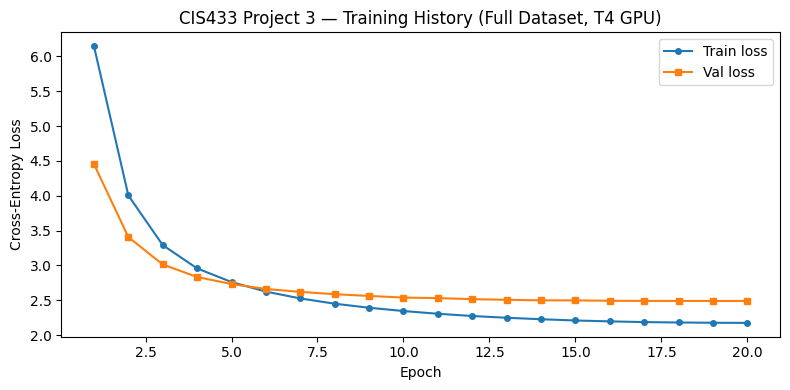

Saved: saved_model/loss_curve.png + mirrored to Drive


In [16]:
with open(MODEL_DIR / 'history.pkl', 'rb') as f:
    hist = pickle.load(f)

epochs_range = range(1, len(hist['train']) + 1)
plt.figure(figsize=(8, 4))
plt.plot(epochs_range, hist['train'], marker='o', ms=4, label='Train loss')
plt.plot(epochs_range, hist['val'],   marker='s', ms=4, label='Val loss')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.title('CIS433 Project 3 — Training History (Full Dataset, T4 GPU)')
plt.legend()
plt.tight_layout()
plt.savefig(MODEL_DIR / 'loss_curve.png', dpi=150)
shutil.copy(MODEL_DIR / 'loss_curve.png', DRIVE_SAVE / 'loss_curve.png')
plt.show()
print('Saved: saved_model/loss_curve.png + mirrored to Drive')


## 14 · Interactive Translator
Type any English sentence. Type `quit` to exit.

In [17]:
print('=' * 52)
print('   English -> Spanish Transformer Translator')
print("   Type 'quit' to exit")
print('=' * 52)

while True:
    try:
        user_input = input('\nEnglish : ').strip()
    except (EOFError, KeyboardInterrupt):
        print('\nGoodbye!')
        break

    if user_input.lower() in {'quit', 'exit', 'q', ''}:
        print('Goodbye!')
        break

    spanish = translate(user_input, inf_model, inf_sv, inf_tv, inf_cfg)
    print(f'Spanish: {spanish}')


   English -> Spanish Transformer Translator
   Type 'quit' to exit

English : i want to be rich
Spanish: quiero ser rico .

English : quit
Goodbye!
